---
date: "2026-06-21"
date-modified: last-modified
format:
  html:
    toc: true
---


# Signal Provider Selection via Multi-Armed Bandits

## 1\. Introduction & Problem Formulation

### The Real-World Problem

Many retail traders subscribe to **signal providers** -- experts who publish buy/sell recommendations through Discord, Telegram, or similar channels. Initially, a provider might seem profitable, but their edge can fade, shift, or disappear over time. When you have access to *multiple* providers, a natural question arises:

> **Can we dynamically allocate our capital across signal providers to maximize returns, even when provider quality changes over time?**

This is a classic **Multi-Armed Bandit (MAB)** / **online learning** problem. The "arms" are signal providers, the "rewards" are trade outcomes, and the challenge is balancing **exploration** (testing providers whose quality is uncertain) with **exploitation** (following the currently best provider).

### Key Challenges

1. **Non-stationarity**: Provider quality changes across market regimes
2. **Delayed feedback**: A trade opened now might not close for hours -- the MAB only learns when the trade exits
3. **Partial information (Bandit setting)**: We only observe the outcome of the provider we followed

### Formal Setup

Let $K$ signal providers (experts) generate signals over $T$ rounds. At each round $t$:

- Each expert $k$ issues a signal $s_{k,t} \in \{+1, -1\}$ (long / short)
- The learner selects a distribution $\pi_t$ over experts and samples $I_t \sim \pi_t$
- A trade is opened following expert $I_t$'s signal
- When the trade exits (at some delayed time $\tau_t > t$), reward $r_{I_t,t}$ is observed

**Regret** measures how much worse we did compared to the best strategy:

$$R_T^{\text{static}} = \max_{k \in [K]} \sum_{t=1}^{T} r_{k,t} \;-\; \sum_{t=1}^{T} r_{I_t,t}$$

$$R_T^{\text{dynamic}} = \sum_{t=1}^{T} \max_{k \in [K]} r_{k,t} \;-\; \sum_{t=1}^{T} r_{I_t,t}$$

We study how different MAB algorithms minimize these regret quantities under realistic trading conditions.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# -- Plotting --
ALGO_COLORS = {
    'Uniform Random': '#9E9E9E',
    'Follow-the-Leader': '#795548',
    'UCB1': '#2196F3',
    'Thompson Sampling': '#4CAF50',
    'Discounted UCB': '#FF5722',
    'SW-UCB': '#FF9800',
    'EXP3': '#9C27B0',
    'EXP3.S': '#E91E63',
    'Fixed-Share': '#00BCD4',
    'Oracle': '#FFD700',
}

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'lines.linewidth': 2,
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
})

# -- Simulation Parameters --
S0          = 100
MU          = 0
SIGMA       = 0.20
MIN_PER_DAY = 390
N_DAYS      = 20
N_STEPS     = MIN_PER_DAY * N_DAYS
DT          = 1.0 / (252 * MIN_PER_DAY)
N_PATHS     = 1000
N_EXPERTS   = 10
SIG_INTERVAL    = 30
DIR_LOOKFWD     = 60
TP_PCT      = 0.01
SL_PCT      = 0.01
TIME_BARRIER = MIN_PER_DAY

# -- Expert Profiles --
EXPERT_PROFILES = np.array([
    [0.55, 0.55, 0.55, 0.55],  # E1  Consistently decent
    [0.70, 0.30, 0.70, 0.30],  # E2  Oscillating hot/cold
    [0.30, 0.70, 0.30, 0.70],  # E3  Inverse of E2
    [0.80, 0.50, 0.40, 0.50],  # E4  Early star, fades
    [0.40, 0.50, 0.50, 0.80],  # E5  Late bloomer
    [0.45, 0.45, 0.45, 0.45],  # E6  Consistently mediocre
    [0.35, 0.35, 0.35, 0.35],  # E7  Consistently bad
    [0.60, 0.60, 0.30, 0.60],  # E8  Occasional crash
    [0.50, 0.50, 0.50, 0.50],  # E9  Coin-flip baseline
    [0.30, 0.30, 0.30, 0.30],  # E10 Always bad
])

EXPERT_NAMES = [
    'E1: Consistent', 'E2: Hot/Cold', 'E3: Inverse',
    'E4: Early Star', 'E5: Late Bloomer', 'E6: Mediocre',
    'E7: Bad', 'E8: Crash Risk', 'E9: Coin Flip', 'E10: Always Bad'
]

N_REGIMES = 4
REG_LEN   = N_DAYS // N_REGIMES
REG_BOUNDS = [i * REG_LEN * MIN_PER_DAY for i in range(N_REGIMES + 1)]

SEED = 42
print("Configuration loaded")


Configuration loaded



## 2\. Price Simulation: Geometric Brownian Motion

We model the asset price as a **Geometric Brownian Motion (GBM)**:

$$dS_t = \mu S_t\, dt + \sigma S_t\, dW_t$$

Discretised (Euler-Maruyama):

$$S_{t+1} = S_t \exp\!\left[\left(\mu - \tfrac{\sigma^2}{2}\right)\Delta t + \sigma\sqrt{\Delta t}\, Z_t\right], \quad Z_t \sim \mathcal{N}(0,1)$$

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| $S_0$ | 100 | Arbitrary starting price |
| $\mu$ | 0 | Drift-free (fair market) |
| $\sigma$ | 0.20 (ann.) | Typical equity volatility |
| $\Delta t$ | 1 min | High-resolution |
| Duration | 20 trading days | About 7 800 bars |
| Realisations | 1 000 | Publication quality |

::: {.callout-note}
## Why zero drift?
Setting $\mu = 0$ ensures a **fair market** where no directional bias exists. Any profitability must come from expert timing skill, not from free ride on a trend.
:::


Price paths: (1000, 7801)  |  range [83.47, 119.89]


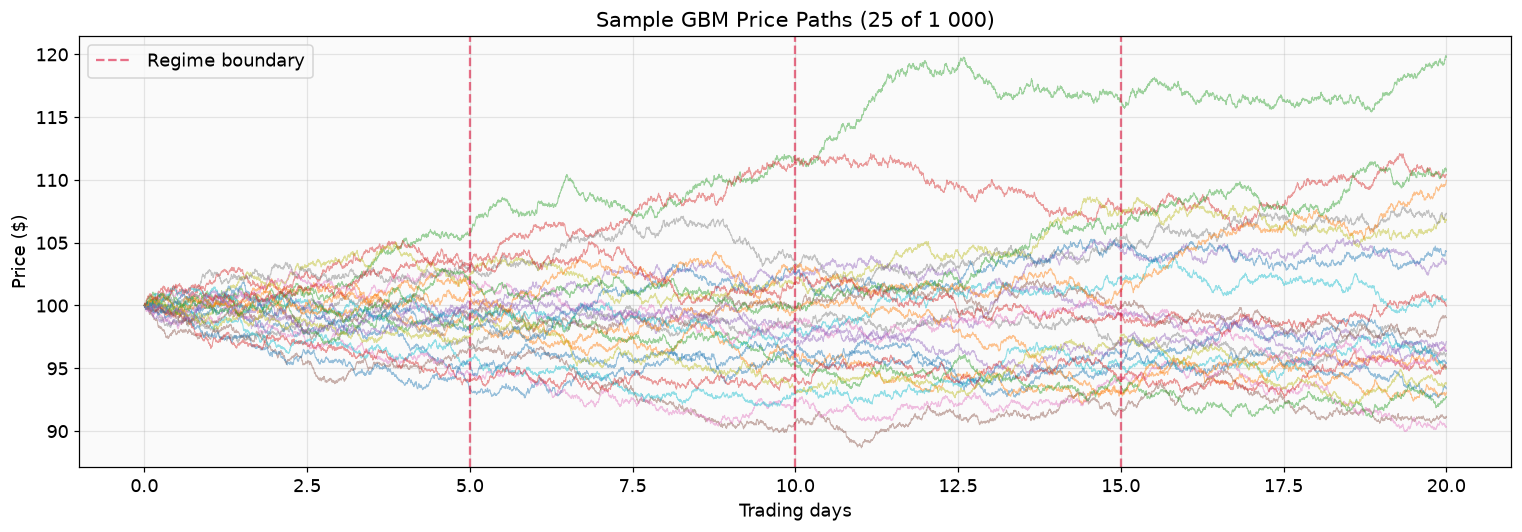

In [2]:
def simulate_gbm(S0, mu, sigma, dt, n_steps, n_paths, rng):
    """Simulate Geometric Brownian Motion price paths."""
    Z = rng.standard_normal((n_paths, n_steps))
    drift = (mu - 0.5 * sigma**2) * dt
    diffusion = sigma * np.sqrt(dt) * Z
    log_ret = drift + diffusion
    log_prices = np.cumsum(log_ret, axis=1)
    prices = S0 * np.exp(np.column_stack([np.zeros(n_paths), log_prices]))
    return prices


rng_data = np.random.default_rng(SEED)
prices = simulate_gbm(S0, MU, SIGMA, DT, N_STEPS, N_PATHS, rng_data)
print(f"Price paths: {prices.shape}  |  range [{prices.min():.2f}, {prices.max():.2f}]")

fig, ax = plt.subplots(figsize=(14, 5))
t_days = np.arange(N_STEPS + 1) / MIN_PER_DAY
for i in range(25):
    ax.plot(t_days, prices[i], alpha=0.45, linewidth=0.7)
for b in REG_BOUNDS[1:-1]:
    ax.axvline(b / MIN_PER_DAY, color='crimson', ls='--', alpha=0.6, lw=1.5,
               label='Regime boundary' if b == REG_BOUNDS[1] else '')
ax.set_xlabel('Trading days')
ax.set_ylabel('Price ($)')
ax.set_title('Sample GBM Price Paths (25 of 1 000)')
ax.legend()
plt.tight_layout(); plt.show()



## 3\. Expert (Signal Provider) Design

We create **10 experts** with **regime-dependent** quality. The 20-day horizon is split into **4 regimes** of 5 days each. Each expert has an accuracy $\alpha_k^{(r)}$: the probability of signalling the correct direction in regime $r$.

| Expert | Profile | R1 | R2 | R3 | R4 |
|--------|---------|:---:|:---:|:---:|:---:|
| E1 | Consistently decent | 0.55 | 0.55 | 0.55 | 0.55 |
| E2 | Oscillating hot/cold | 0.70 | 0.30 | 0.70 | 0.30 |
| E3 | Inverse of E2 | 0.30 | 0.70 | 0.30 | 0.70 |
| E4 | Early star, fades | 0.80 | 0.50 | 0.40 | 0.50 |
| E5 | Late bloomer | 0.40 | 0.50 | 0.50 | 0.80 |
| E6 | Consistently mediocre | 0.45 | 0.45 | 0.45 | 0.45 |
| E7 | Consistently bad | 0.35 | 0.35 | 0.35 | 0.35 |
| E8 | Occasional crash | 0.60 | 0.60 | 0.30 | 0.60 |
| E9 | Coin-flip baseline | 0.50 | 0.50 | 0.50 | 0.50 |
| E10 | Always bad | 0.30 | 0.30 | 0.30 | 0.30 |

**Signal generation**: at each round we look at the price 60 min ahead to determine the "correct" direction. Expert $k$ in regime $r$ issues the correct direction with probability $\alpha_k^{(r)}$.


Signal rounds: 248  |  directions shape: (1000, 248, 10)


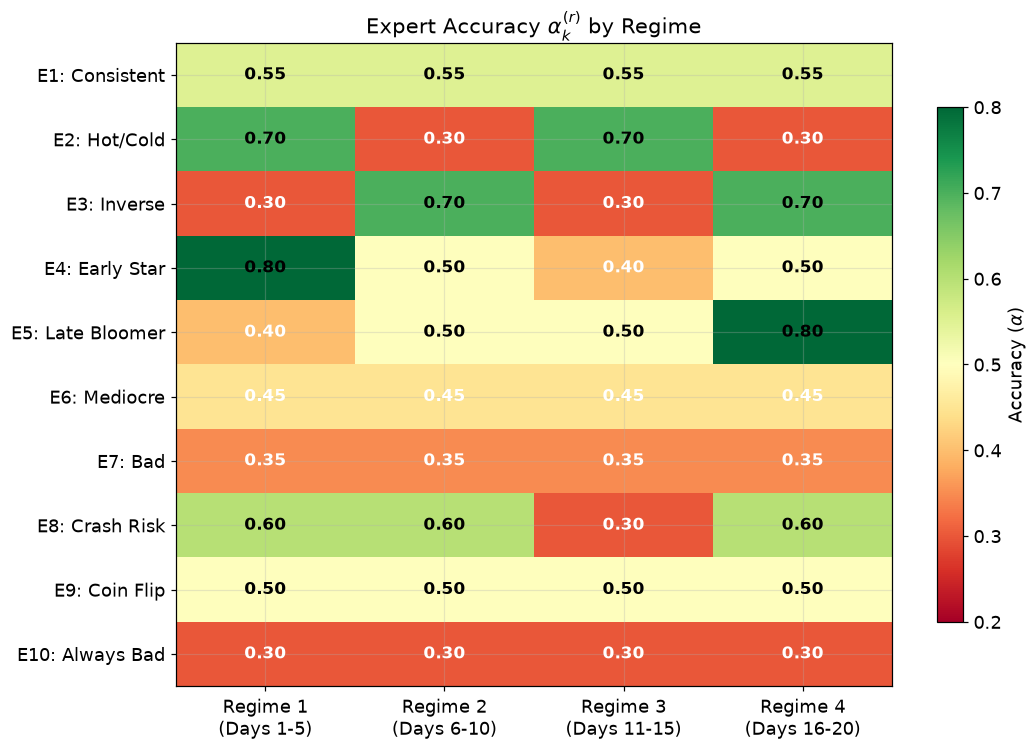

In [3]:
def get_regime(t, bounds):
    """Return regime index for timestep t."""
    for r in range(len(bounds) - 1):
        if bounds[r] <= t < bounds[r + 1]:
            return r
    return len(bounds) - 2


def generate_signals(prices, profiles, bounds,
                     interval, lookfwd, barrier, rng):
    """Generate expert signals for all paths."""
    n_paths, n_steps_p1 = prices.shape
    n_experts = profiles.shape[0]
    n_steps = n_steps_p1 - 1

    max_entry = n_steps - barrier
    rtimes = np.arange(0, max_entry + 1, interval)
    rtimes = rtimes[rtimes + lookfwd <= n_steps]
    n_rounds = len(rtimes)

    entry_pr  = prices[:, rtimes]
    future_pr = prices[:, rtimes + lookfwd]
    mkt_dir   = np.sign(future_pr - entry_pr)
    zero = mkt_dir == 0
    mkt_dir[zero] = rng.choice([-1, 1], size=int(zero.sum()))

    dirs = np.zeros((n_paths, n_rounds, n_experts), dtype=np.int8)
    for ri, t in enumerate(rtimes):
        reg = get_regime(t, bounds)
        for k in range(n_experts):
            alpha = profiles[k, reg]
            correct = rng.random(n_paths) < alpha
            dirs[:, ri, k] = np.where(correct, mkt_dir[:, ri],
                                       -mkt_dir[:, ri])
    return rtimes, dirs

round_times, directions = generate_signals(
    prices, EXPERT_PROFILES, REG_BOUNDS,
    SIG_INTERVAL, DIR_LOOKFWD, TIME_BARRIER, rng_data
)
n_rounds = len(round_times)
print(f"Signal rounds: {n_rounds}  |  directions shape: {directions.shape}")

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(EXPERT_PROFILES, cmap='RdYlGn', aspect='auto',
               vmin=0.20, vmax=0.80)
ax.set_xticks(range(N_REGIMES))
ax.set_xticklabels([f'Regime {i+1}\n(Days {i*5+1}-{(i+1)*5})'
                    for i in range(N_REGIMES)])
ax.set_yticks(range(N_EXPERTS))
ax.set_yticklabels(EXPERT_NAMES)
ax.set_title(r'Expert Accuracy $\alpha_k^{(r)}$ by Regime')
for i in range(N_EXPERTS):
    for j in range(N_REGIMES):
        clr = 'black' if EXPERT_PROFILES[i, j] > 0.45 else 'white'
        ax.text(j, i, f'{EXPERT_PROFILES[i,j]:.2f}',
                ha='center', va='center', color=clr,
                fontweight='bold', fontsize=11)
plt.colorbar(im, ax=ax, label=r'Accuracy ($\alpha$)', shrink=0.8)
plt.tight_layout(); plt.show()


## 4\. Triple Barrier Method

Each signal is evaluated using the **triple barrier method**:

| Barrier | Condition (long trade) | PnL |
|---------|----------------------|-----|
| Take-Profit | $S_t \geq 1.01\,S_{\text{entry}}$ | $+1\%$ |
| Stop-Loss | $S_t \leq 0.99\,S_{\text{entry}}$ | $-1\%$ |
| Time | 390 min elapsed, neither hit | $(S_{t+390}/S_{\text{entry}})-1$ |

Short signals mirror the logic.

::: {.callout-important}
## Delayed Feedback -- The Central Challenge
The **exit time** creates a natural **feedback delay**. The MAB algorithm cannot learn from a trade until it closes -- anywhere from 1 minute (instant barrier hit) to 390 minutes (time barrier). This distinguishes our setup from standard MAB.
:::


Evaluating trades with triple barrier ...
PnL shape: (1000, 248, 10)


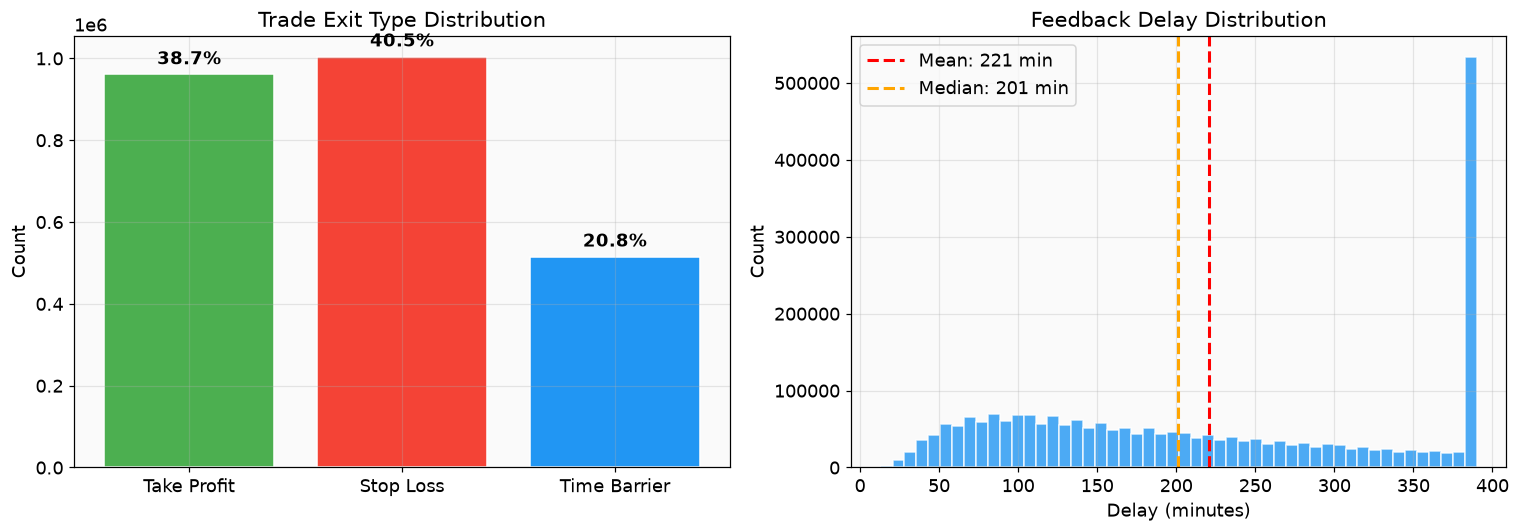


Mean PnL per Expert (across all paths & rounds):
  E1: Consistent        : Mean PnL = +0.0369%  |  Win Rate = 51.85%
  E2: Hot/Cold          : Mean PnL = +0.0081%  |  Win Rate = 50.39%
  E3: Inverse           : Mean PnL = -0.0069%  |  Win Rate = 49.68%
  E4: Early Star        : Mean PnL = +0.0411%  |  Win Rate = 52.10%
  E5: Late Bloomer      : Mean PnL = +0.0282%  |  Win Rate = 51.45%
  E6: Mediocre          : Mean PnL = -0.0351%  |  Win Rate = 48.24%
  E7: Bad               : Mean PnL = -0.1098%  |  Win Rate = 44.48%
  E8: Crash Risk        : Mean PnL = +0.0129%  |  Win Rate = 50.60%
  E9: Coin Flip         : Mean PnL = +0.0031%  |  Win Rate = 50.13%
  E10: Always Bad       : Mean PnL = -0.1546%  |  Win Rate = 42.24%


In [4]:
def _eval_dir(returns, tp, sl, barrier,
              out_pnl, out_delay, out_type, ri):
    """Evaluate one direction (long or short) across all paths."""
    tp_mask = returns >= tp
    sl_mask = returns <= -sl

    tp_1st = np.argmax(tp_mask, axis=1)
    tp_ok  = np.any(tp_mask, axis=1)
    sl_1st = np.argmax(sl_mask, axis=1)
    sl_ok  = np.any(sl_mask, axis=1)

    tp_wins = tp_ok & (~sl_ok | (tp_1st <= sl_1st))
    out_pnl[tp_wins, ri]   =  tp
    out_delay[tp_wins, ri]  = tp_1st[tp_wins] + 1
    out_type[tp_wins, ri]   = 0

    sl_wins = sl_ok & (~tp_ok | (sl_1st < tp_1st))
    out_pnl[sl_wins, ri]   = -sl
    out_delay[sl_wins, ri]  = sl_1st[sl_wins] + 1
    out_type[sl_wins, ri]   = 1

    time_exit = ~tp_ok & ~sl_ok
    if barrier > 0 and returns.shape[1] > 0:
        out_pnl[time_exit, ri] = returns[time_exit, -1]
    out_delay[time_exit, ri] = barrier
    out_type[time_exit, ri]  = 2


def evaluate_trades(prices, rtimes, dirs, tp, sl, barrier):
    """Triple-barrier evaluation (vectorised over paths)."""
    n_paths = prices.shape[0]
    n_steps = prices.shape[1] - 1
    n_rds   = len(rtimes)
    n_exp   = dirs.shape[2]

    l_pnl = np.zeros((n_paths, n_rds))
    l_del = np.zeros((n_paths, n_rds), dtype=np.int32)
    l_typ = np.full((n_paths, n_rds), 2, dtype=np.int8)
    s_pnl = np.zeros((n_paths, n_rds))
    s_del = np.zeros((n_paths, n_rds), dtype=np.int32)
    s_typ = np.full((n_paths, n_rds), 2, dtype=np.int8)

    for ri, entry in enumerate(rtimes):
        ep  = prices[:, entry]
        end = min(entry + barrier, n_steps)
        ab  = end - entry
        if ab <= 0:
            continue
        win = prices[:, entry+1:end+1]
        ret = win / ep[:, None] - 1
        _eval_dir( ret, tp, sl, ab, l_pnl, l_del, l_typ, ri)
        _eval_dir(-ret, tp, sl, ab, s_pnl, s_del, s_typ, ri)

    pnl  = np.zeros((n_paths, n_rds, n_exp))
    edel = np.zeros((n_paths, n_rds, n_exp), dtype=np.int32)
    etyp = np.zeros((n_paths, n_rds, n_exp), dtype=np.int8)
    for k in range(n_exp):
        lm = dirs[:, :, k] == 1
        pnl[:,:,k]  = np.where(lm, l_pnl, s_pnl)
        edel[:,:,k] = np.where(lm, l_del, s_del)
        etyp[:,:,k] = np.where(lm, l_typ, s_typ)
    return pnl, edel, etyp


print("Evaluating trades with triple barrier ...")
pnl, exit_delays, exit_types = evaluate_trades(
    prices, round_times, directions, TP_PCT, SL_PCT, TIME_BARRIER
)
print(f"PnL shape: {pnl.shape}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

all_t = exit_types.flatten()
cnts  = [np.sum(all_t == t) for t in range(3)]
labs  = ['Take Profit', 'Stop Loss', 'Time Barrier']
clrs  = ['#4CAF50', '#F44336', '#2196F3']
axes[0].bar(labs, cnts, color=clrs, edgecolor='white')
axes[0].set_title('Trade Exit Type Distribution')
axes[0].set_ylabel('Count')
for i, (c, l) in enumerate(zip(cnts, labs)):
    axes[0].text(i, c + len(all_t)*0.01, f'{100*c/len(all_t):.1f}%',
                 ha='center', fontweight='bold')

ad = exit_delays.flatten()
axes[1].hist(ad, bins=50, color='#2196F3', edgecolor='white', alpha=0.8)
axes[1].axvline(np.mean(ad), color='red', ls='--',
               label=f'Mean: {np.mean(ad):.0f} min')
axes[1].axvline(np.median(ad), color='orange', ls='--',
               label=f'Median: {np.median(ad):.0f} min')
axes[1].set_title('Feedback Delay Distribution')
axes[1].set_xlabel('Delay (minutes)')
axes[1].set_ylabel('Count')
axes[1].legend()
plt.tight_layout(); plt.show()

print("\nMean PnL per Expert (across all paths & rounds):")
for k in range(N_EXPERTS):
    mp = np.mean(pnl[:,:,k])
    wr = np.mean(pnl[:,:,k] > 0)
    print(f"  {EXPERT_NAMES[k]:<22}: Mean PnL = {mp*100:>+7.4f}%  "
          f"|  Win Rate = {wr:.2%}")


## 5\. MAB Problem Formulation

### Decision Process

At each signal round $t$ (every 30 minutes):

1. **Process exits**: check if any pending trades have closed -- feed their rewards to the algorithm (delayed feedback)
2. **Select expert**: the algorithm outputs $I_t \sim \pi_t$
3. **Open trade**: follow expert $I_t$'s signal
4. **Queue trade**: schedule for exit at $t + \delta_t$

### Reward Normalisation

Raw PnL lies in $[-\text{SL\%},\, +\text{TP\%}]$. We normalise to $[0,1]$:

$$\hat{r} = \frac{r + \text{SL\%}}{\text{TP\%} + \text{SL\%}}$$

For Thompson Sampling (Beta posterior) we binarise: $\hat{r} = \mathbf{1}[r > 0]$.


## 6\. MAB Algorithms

### Baselines
- **Uniform Random**: select expert uniformly at random (no learning)
- **Follow-the-Leader (FTL)**: always pick the expert with highest average observed reward

### Stationary Algorithms

**UCB1** (Upper Confidence Bound):
$$I_t = \arg\max_k \left[\hat{\mu}_k + \sqrt{\frac{2\ln t}{n_k}}\right]$$

**Thompson Sampling**: maintain Beta posterior $\operatorname{Beta}(\alpha_k, \beta_k)$ per expert; sample $\theta_k \sim \operatorname{Beta}(\alpha_k, \beta_k)$ and pick $I_t = \arg\max_k \theta_k$.

### Non-Stationary Algorithms

**Discounted UCB (D-UCB)**: like UCB1 but with exponentially discounted history ($\gamma \in (0,1)$):
$$\hat{\mu}_k^{(\gamma)} = \frac{\sum_{s\le t}\gamma^{t-s}\, r_{k,s}}{N_k^{(\gamma)}}$$

**Sliding-Window UCB (SW-UCB)**: only uses the last $\tau$ observations per arm.

**EXP3**: exponential-weight algorithm for adversarial bandits. Draws arm from
$$p_k = (1-\gamma)\frac{w_k}{\sum_j w_j} + \frac{\gamma}{K}$$

**EXP3.S**: EXP3 with extra uniform weight mixing after each update -- tracks shifting best expert.

**Fixed-Share** (Herbster & Warmuth): after each multiplicative-weights update, redistributes fraction $\alpha$ of each expert's weight uniformly. Designed for tracking the best expert with switches.


In [5]:
def norm_reward(pnl, tp=TP_PCT, sl=SL_PCT):
    """Normalise PnL to [0, 1]."""
    return (pnl + sl) / (tp + sl)


# -- Baselines --

class UniformRandom:
    def __init__(self, K): self.K = K
    def reset(self): pass
    def select_arm(self): return np.random.randint(self.K)
    def update(self, arm, reward): pass


class FollowTheLeader:
    def __init__(self, K):
        self.K = K; self.reset()
    def reset(self):
        self.totals = np.zeros(self.K)
        self.counts = np.zeros(self.K)
    def select_arm(self):
        if np.min(self.counts) == 0:
            return int(np.argmin(self.counts))
        return int(np.argmax(self.totals / self.counts))
    def update(self, arm, reward):
        self.totals[arm] += norm_reward(reward)
        self.counts[arm] += 1


# -- Stationary --

class UCB1:
    def __init__(self, K):
        self.K = K; self.reset()
    def reset(self):
        self.totals = np.zeros(self.K)
        self.counts = np.zeros(self.K)
        self.t = 0
    def select_arm(self):
        self.t += 1
        if np.min(self.counts) == 0:
            return int(np.argmin(self.counts))
        ucb = (self.totals / self.counts
               + np.sqrt(2 * np.log(self.t) / self.counts))
        return int(np.argmax(ucb))
    def update(self, arm, reward):
        self.totals[arm] += norm_reward(reward)
        self.counts[arm] += 1


class ThompsonSampling:
    def __init__(self, K):
        self.K = K; self.reset()
    def reset(self):
        self.a = np.ones(self.K)
        self.b = np.ones(self.K)
    def select_arm(self):
        return int(np.argmax(np.random.beta(self.a, self.b)))
    def update(self, arm, reward):
        if reward > 0:
            self.a[arm] += 1
        else:
            self.b[arm] += 1


# -- Non-Stationary --

class DiscountedUCB:
    def __init__(self, K, gamma=0.995):
        self.K = K; self.gamma = gamma; self.reset()
    def reset(self):
        self.dr = np.zeros(self.K)
        self.dc = np.zeros(self.K)
        self.dn = 0.0
    def select_arm(self):
        if np.min(self.dc) < 1.0:
            return int(np.argmin(self.dc))
        means = self.dr / self.dc
        expl  = np.sqrt(2 * np.log(self.dn) / self.dc)
        return int(np.argmax(means + expl))
    def update(self, arm, reward):
        r = norm_reward(reward)
        self.dr *= self.gamma
        self.dc *= self.gamma
        self.dn  = self.dn * self.gamma + 1
        self.dr[arm] += r
        self.dc[arm] += 1


class SlidingWindowUCB:
    def __init__(self, K, tau=50):
        self.K = K; self.tau = tau; self.reset()
    def reset(self):
        self.hist = []
        self.t = 0
    def select_arm(self):
        self.t += 1
        rec = self.hist[-self.tau:]
        if len(rec) < self.K:
            seen = {a for a, _ in rec}
            for a in range(self.K):
                if a not in seen:
                    return a
            return np.random.randint(self.K)
        cnts = np.zeros(self.K)
        tots = np.zeros(self.K)
        for a, r in rec:
            cnts[a] += 1; tots[a] += r
        if np.min(cnts) == 0:
            return int(np.argmin(cnts))
        means = tots / cnts
        expl  = np.sqrt(2 * np.log(len(rec)) / cnts)
        return int(np.argmax(means + expl))
    def update(self, arm, reward):
        self.hist.append((arm, norm_reward(reward)))


class EXP3:
    def __init__(self, K, gamma=0.07):
        self.K = K; self.gamma = gamma; self.reset()
    def reset(self):
        self.w = np.ones(self.K)
    def _probs(self):
        s = np.sum(self.w)
        return (1 - self.gamma) * (self.w / s) + self.gamma / self.K
    def select_arm(self):
        return int(np.random.choice(self.K, p=self._probs()))
    def update(self, arm, reward):
        r = norm_reward(reward)
        p = self._probs()
        est = r / p[arm]
        self.w[arm] *= np.exp(self.gamma * est / self.K)
        self.w /= np.max(self.w)


class EXP3S:
    """EXP3.S -- uniform mixing for non-stationary environments."""
    def __init__(self, K, gamma=0.07, alpha=0.002):
        self.K = K; self.gamma = gamma; self.alpha = alpha
        self.reset()
    def reset(self):
        self.w = np.ones(self.K)
    def _probs(self):
        s = np.sum(self.w)
        return (1 - self.gamma) * (self.w / s) + self.gamma / self.K
    def select_arm(self):
        return int(np.random.choice(self.K, p=self._probs()))
    def update(self, arm, reward):
        r = norm_reward(reward)
        p = self._probs()
        est = r / p[arm]
        self.w[arm] *= np.exp(self.gamma * est / self.K)
        total = np.sum(self.w)
        self.w = (1 - self.alpha) * self.w + self.alpha * total / self.K
        self.w /= np.max(self.w)


class FixedShare:
    """Herbster & Warmuth Fixed-Share (bandit variant)."""
    def __init__(self, K, eta=0.5, alpha=0.05):
        self.K = K; self.eta = eta; self.alpha = alpha
        self.reset()
    def reset(self):
        self.w = np.ones(self.K) / self.K
    def select_arm(self):
        return int(np.random.choice(self.K, p=self.w))
    def update(self, arm, reward):
        r = norm_reward(reward)
        est = np.zeros(self.K)
        est[arm] = r / self.w[arm]
        self.w *= np.exp(self.eta * est)
        self.w /= np.sum(self.w)
        self.w = (1 - self.alpha) * self.w + self.alpha / self.K


ALGORITHMS = {
    'Uniform Random':     lambda: UniformRandom(N_EXPERTS),
    'Follow-the-Leader':  lambda: FollowTheLeader(N_EXPERTS),
    'UCB1':               lambda: UCB1(N_EXPERTS),
    'Thompson Sampling':  lambda: ThompsonSampling(N_EXPERTS),
    'Discounted UCB':     lambda: DiscountedUCB(N_EXPERTS, gamma=0.995),
    'SW-UCB':             lambda: SlidingWindowUCB(N_EXPERTS, tau=50),
    'EXP3':               lambda: EXP3(N_EXPERTS, gamma=0.07),
    'EXP3.S':             lambda: EXP3S(N_EXPERTS, gamma=0.07, alpha=0.002),
    'Fixed-Share':        lambda: FixedShare(N_EXPERTS, eta=0.5, alpha=0.05),
}
print(f"Algorithms: {list(ALGORITHMS.keys())}")


Algorithms: ['Uniform Random', 'Follow-the-Leader', 'UCB1', 'Thompson Sampling', 'Discounted UCB', 'SW-UCB', 'EXP3', 'EXP3.S', 'Fixed-Share']


## 7\. Simulation Engine

For each of the 1 000 price realisations and each algorithm:

1. Walk through all signal rounds chronologically
2. At each round: **process exits** (delayed feedback) then **select expert** then **open trade**
3. Record cumulative PnL, arm selections, individual trade outcomes

The **Oracle** is computed after the fact -- it selects the best expert at every round with perfect foresight.


In [6]:
def run_mab_path(algo, pnl_p, edel_p, rtimes):
    """Run one MAB algorithm on one price path."""
    nr = pnl_p.shape[0]
    arms = np.zeros(nr, dtype=np.int32)
    rews = np.zeros(nr)
    cum  = np.zeros(nr)
    pending = []
    c = 0.0

    for r in range(nr):
        now = rtimes[r]
        # delayed feedback
        keep = []
        for ex_t, a, rv in pending:
            if ex_t <= now:
                algo.update(a, rv)
            else:
                keep.append((ex_t, a, rv))
        pending = keep

        # select & record
        a = algo.select_arm()
        arms[r] = a
        rv = pnl_p[r, a]
        rews[r] = rv
        c += rv
        cum[r] = c
        pending.append((now + edel_p[r, a], a, rv))

    for _, a, rv in pending:
        algo.update(a, rv)
    return arms, rews, cum


np.random.seed(SEED)
results = {}

for name, factory in ALGORITHMS.items():
    a_arms = np.zeros((N_PATHS, n_rounds), dtype=np.int32)
    a_rews = np.zeros((N_PATHS, n_rounds))
    a_cum  = np.zeros((N_PATHS, n_rounds))
    for p in tqdm(range(N_PATHS), desc=name, leave=True):
        algo = factory()
        ar, rw, cr = run_mab_path(algo, pnl[p], exit_delays[p],
                                   round_times)
        a_arms[p] = ar; a_rews[p] = rw; a_cum[p] = cr
    results[name] = {'arms': a_arms, 'rewards': a_rews,
                     'cumulative_reward': a_cum}

oracle_rew = np.max(pnl, axis=2)
oracle_cum = np.cumsum(oracle_rew, axis=1)
results['Oracle'] = {'arms': np.argmax(pnl, axis=2),
                     'rewards': oracle_rew,
                     'cumulative_reward': oracle_cum}

total_per_exp = np.sum(pnl, axis=1)
best_single   = np.argmax(total_per_exp, axis=1)
best_single_cum = np.array([
    np.cumsum(pnl[p, :, best_single[p]]) for p in range(N_PATHS)
])

print("\nSimulation complete!")


Fixed-Share: 100%|████████████████████████████████████████████████| 1000/1000 [00:02<00:00, 464.15it/s]


Simulation complete!


## 8\. Results & Analysis


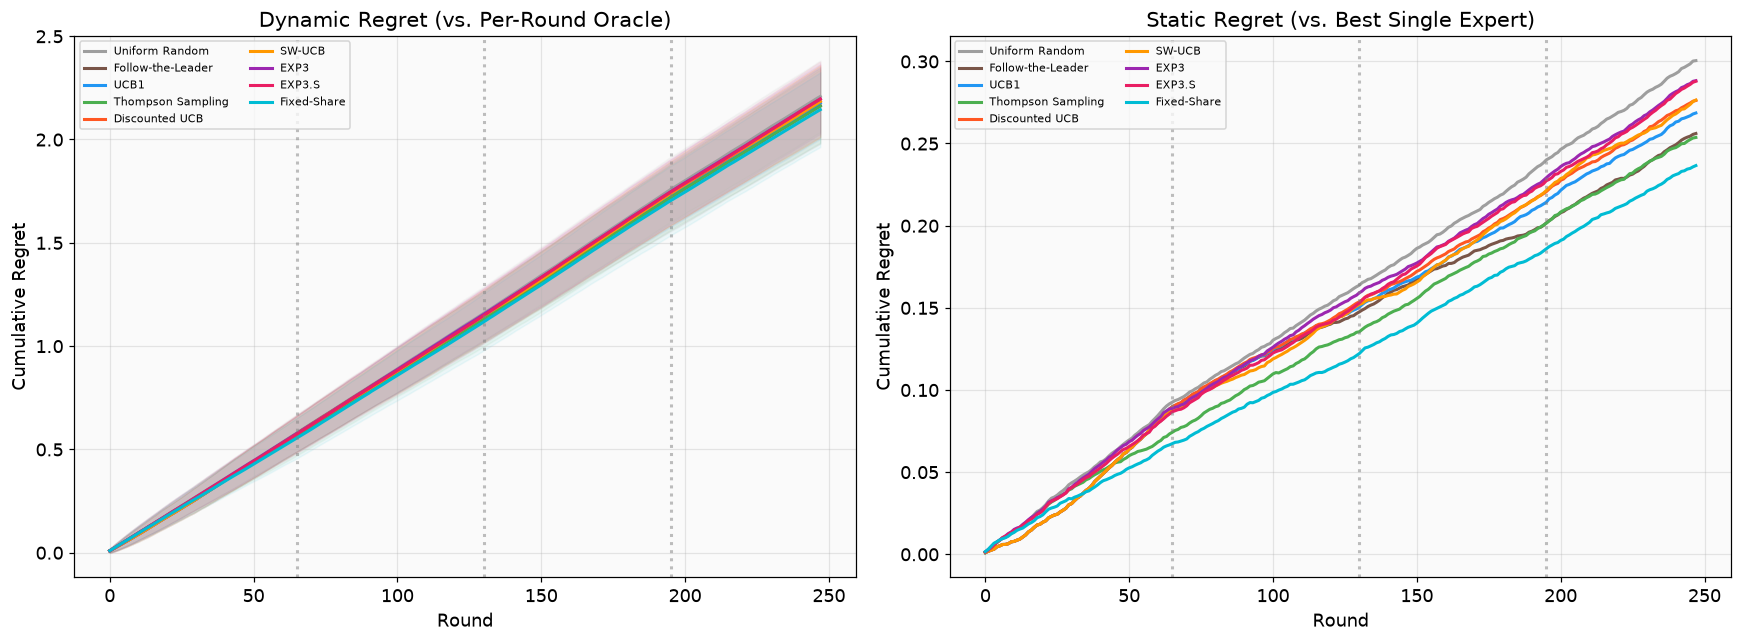

In [7]:
algo_names = list(ALGORITHMS.keys())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for nm in algo_names:
    reg = oracle_cum - results[nm]['cumulative_reward']
    m = np.mean(reg, axis=0); s = np.std(reg, axis=0)
    c = ALGO_COLORS[nm]
    axes[0].plot(m, label=nm, color=c)
    axes[0].fill_between(range(n_rounds), m-s, m+s, alpha=0.06, color=c)
for b in REG_BOUNDS[1:-1]:
    ri = np.searchsorted(round_times, b)
    axes[0].axvline(ri, color='gray', ls=':', alpha=0.5)
axes[0].set_title('Dynamic Regret (vs. Per-Round Oracle)')
axes[0].set_xlabel('Round'); axes[0].set_ylabel('Cumulative Regret')
axes[0].legend(fontsize=7, ncol=2)

for nm in algo_names:
    sr = best_single_cum - results[nm]['cumulative_reward']
    axes[1].plot(np.mean(sr, axis=0), label=nm, color=ALGO_COLORS[nm])
for b in REG_BOUNDS[1:-1]:
    ri = np.searchsorted(round_times, b)
    axes[1].axvline(ri, color='gray', ls=':', alpha=0.5)
axes[1].set_title('Static Regret (vs. Best Single Expert)')
axes[1].set_xlabel('Round'); axes[1].set_ylabel('Cumulative Regret')
axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout(); plt.show()


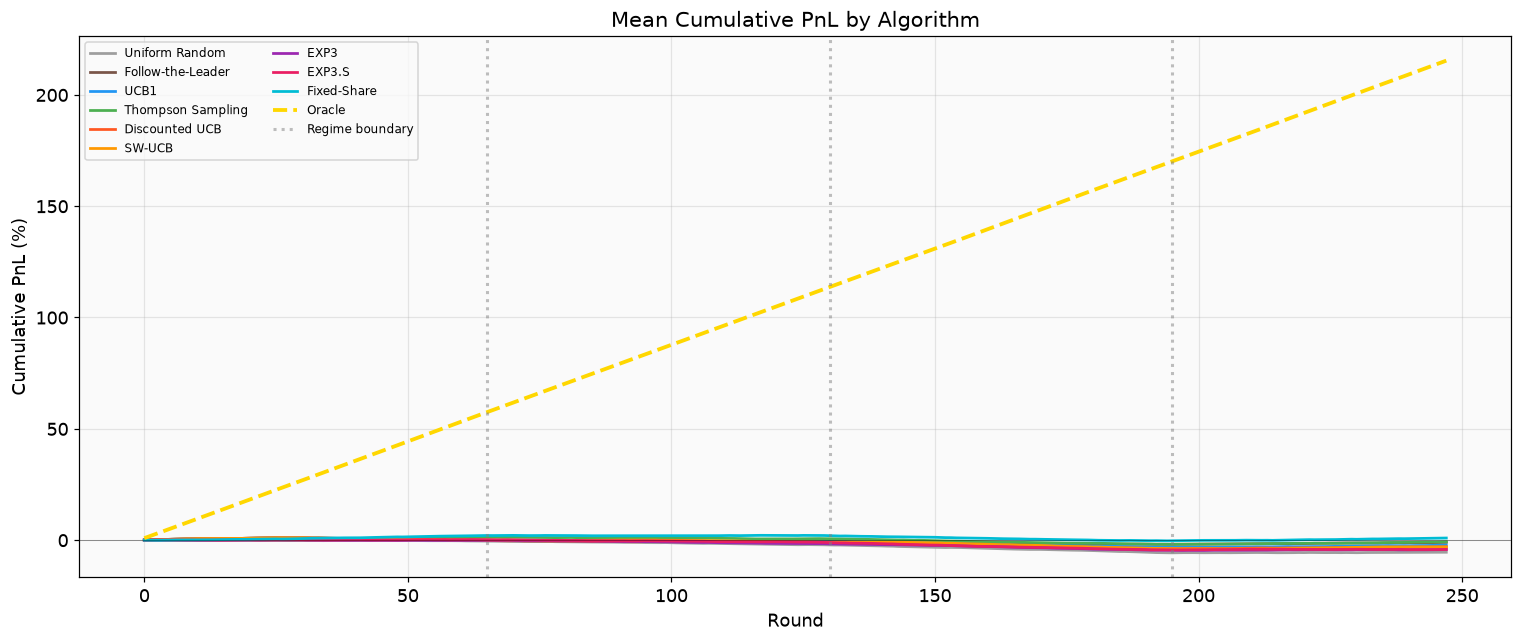

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

for nm in algo_names + ['Oracle']:
    cr = results[nm]['cumulative_reward']
    m  = np.mean(cr, axis=0) * 100
    lw = 2.5 if nm == 'Oracle' else 1.8
    ls = '--' if nm == 'Oracle' else '-'
    ax.plot(m, label=nm, color=ALGO_COLORS[nm], linewidth=lw, linestyle=ls)

for i, b in enumerate(REG_BOUNDS[1:-1]):
    ri = np.searchsorted(round_times, b)
    ax.axvline(ri, color='gray', ls=':', alpha=0.5,
              label='Regime boundary' if i == 0 else '')
ax.axhline(0, color='black', lw=0.5, alpha=0.5)
ax.set_title('Mean Cumulative PnL by Algorithm')
ax.set_xlabel('Round'); ax.set_ylabel('Cumulative PnL (%)')
ax.legend(fontsize=8, ncol=2, loc='upper left')
plt.tight_layout(); plt.show()


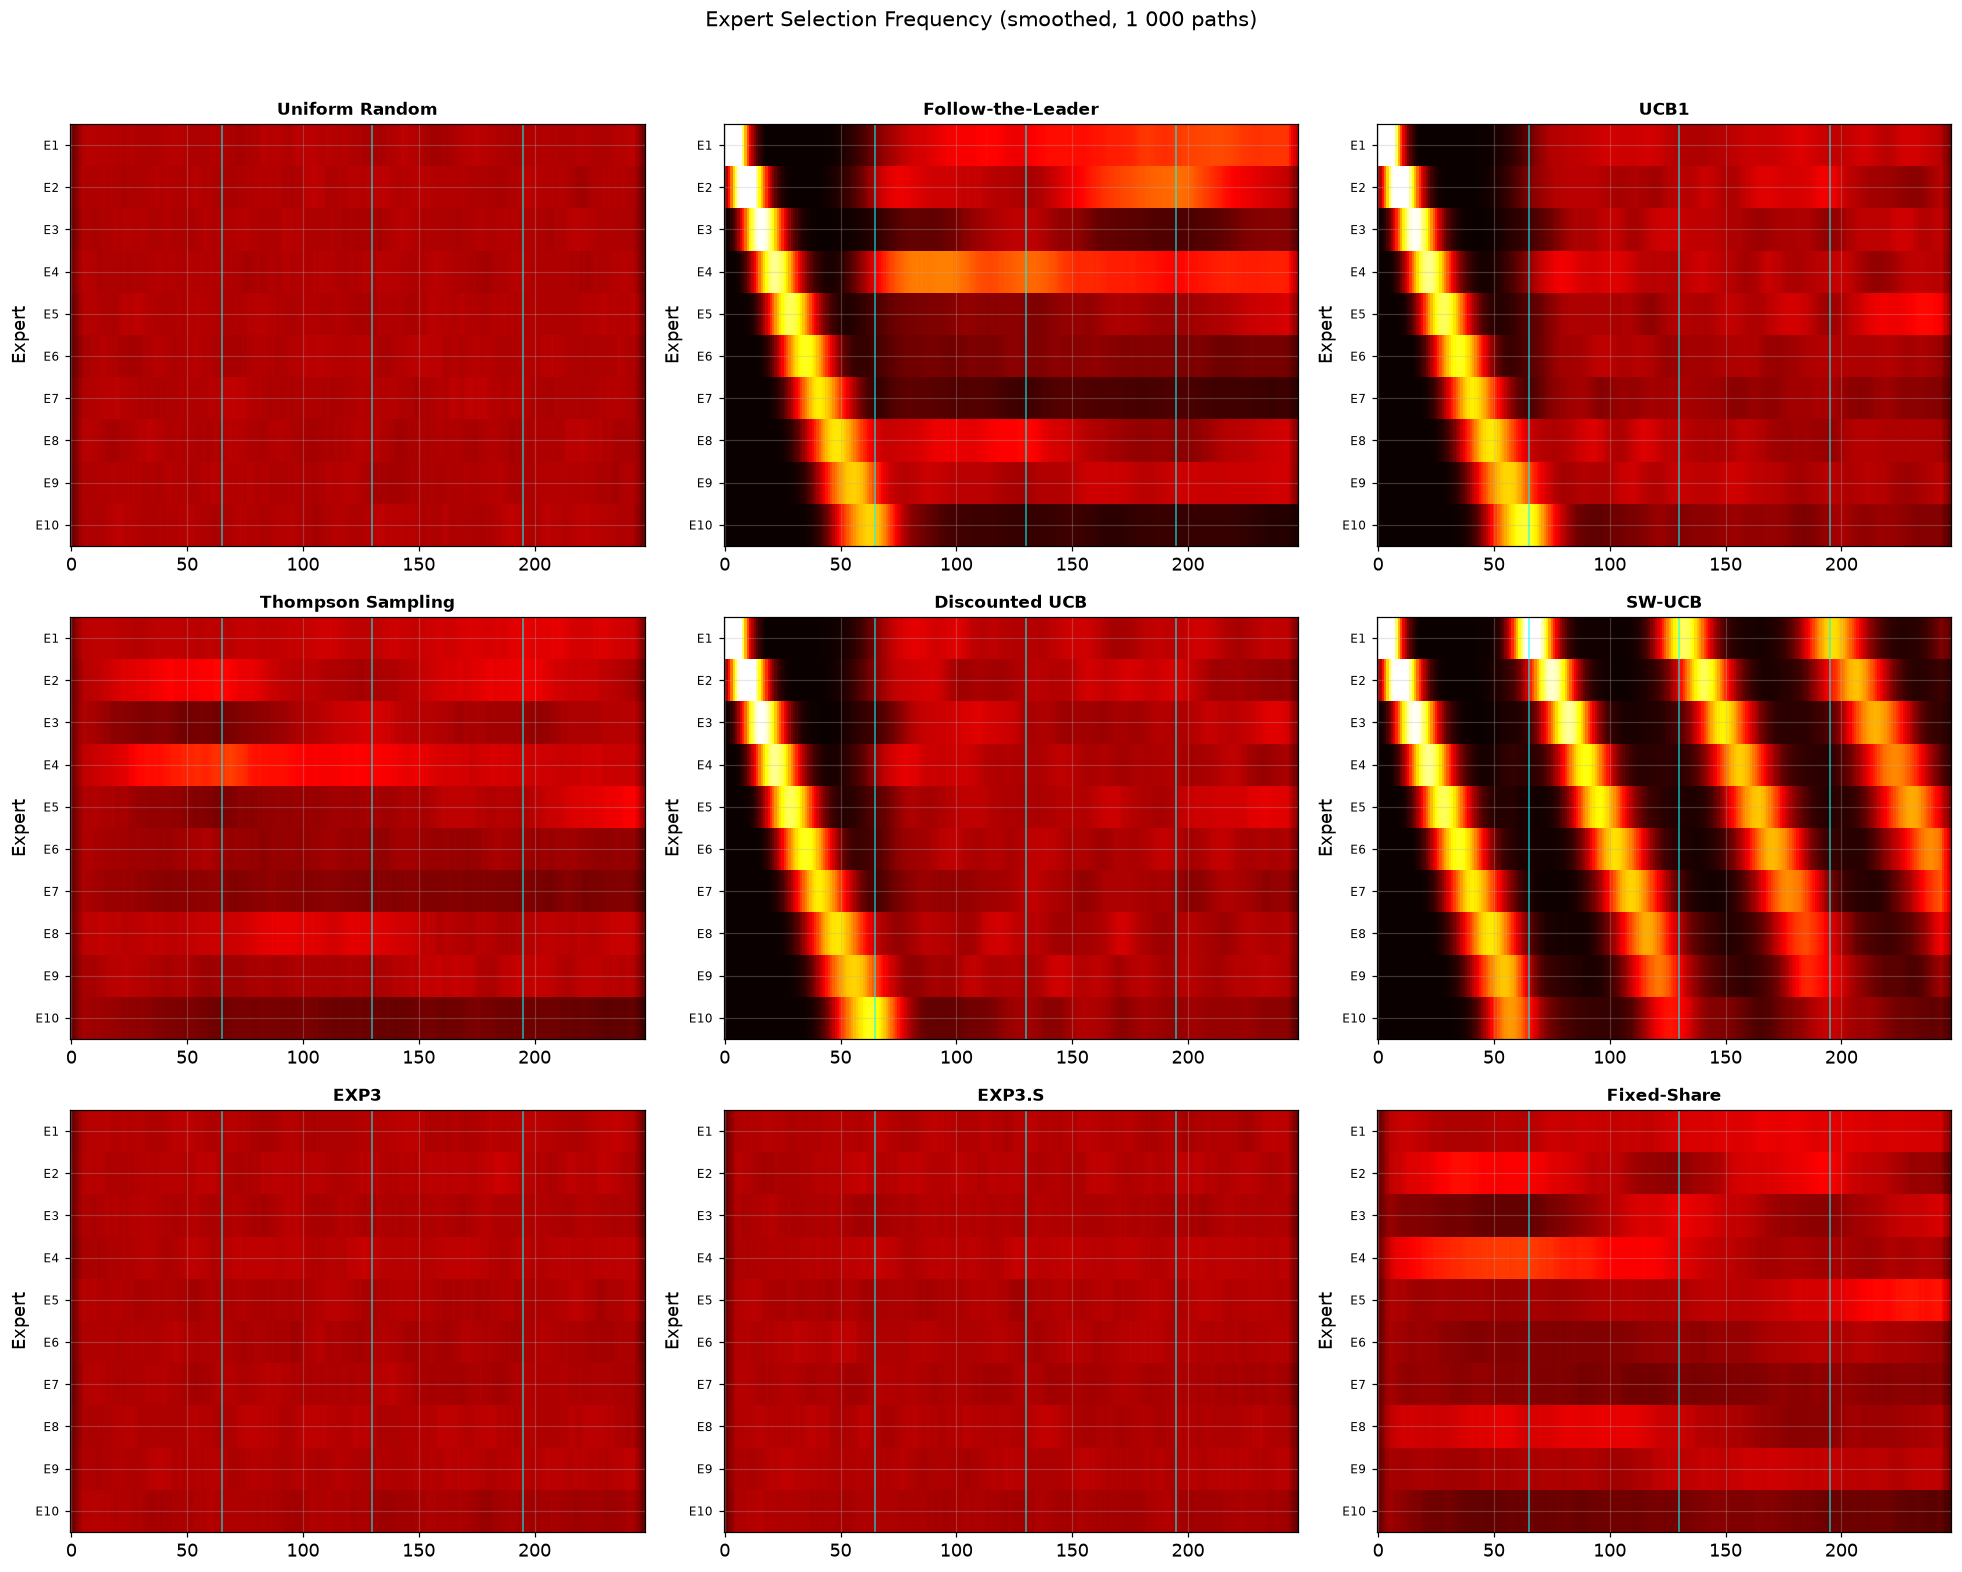

In [9]:
def smooth1d(data, w=10):
    """Row-wise moving average."""
    k = np.ones(w) / w
    return np.array([np.convolve(row, k, mode='same') for row in data])

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axf = axes.flatten()

for idx, nm in enumerate(algo_names):
    ax = axf[idx]
    arms = results[nm]['arms']
    freq = np.zeros((N_EXPERTS, n_rounds))
    for k in range(N_EXPERTS):
        freq[k] = np.mean(arms == k, axis=0)
    sm = smooth1d(freq, w=10)
    ax.imshow(sm, aspect='auto', cmap='hot', vmin=0, vmax=0.4,
              interpolation='nearest')
    ax.set_title(nm, fontsize=11, fontweight='bold')
    ax.set_ylabel('Expert')
    ax.set_yticks(range(N_EXPERTS))
    ax.set_yticklabels([f'E{i+1}' for i in range(N_EXPERTS)], fontsize=8)
    for b in REG_BOUNDS[1:-1]:
        ri = np.searchsorted(round_times, b)
        ax.axvline(ri, color='cyan', lw=1, alpha=0.7)

for idx in range(len(algo_names), len(axf)):
    fig.delaxes(axf[idx])

plt.suptitle('Expert Selection Frequency (smoothed, 1 000 paths)',
             fontsize=14, y=1.02)
plt.tight_layout(); plt.show()


In [10]:
header = (f"{'Algorithm':<22} {'Dyn.Regret':>11} {'Sta.Regret':>11} "
         f"{'PnL%':>9} {'WinRate':>9} {'Sharpe':>8}")
print("=" * len(header))
print(header)
print("=" * len(header))

for nm in algo_names + ['Oracle']:
    cr = results[nm]['cumulative_reward']
    rw = results[nm]['rewards']
    fpnl = np.mean(cr[:, -1]) * 100

    dr = np.mean(oracle_cum[:, -1] - cr[:, -1])
    sr = (np.mean(best_single_cum[:, -1] - cr[:, -1])
          if nm != 'Oracle'
          else np.mean(oracle_cum[:, -1] - best_single_cum[:, -1]))

    wr = np.mean(rw > 0)
    mr = np.mean(rw); sdr = np.std(rw)
    sh = mr / sdr if sdr > 0 else 0.0

    tag = ' *' if nm in ('Thompson Sampling', 'EXP3.S',
                          'Fixed-Share', 'Discounted UCB') else ''
    print(f"{nm:<22} {dr:>11.4f} {sr:>11.4f} "
          f"{fpnl:>+9.3f} {wr:>9.2%} {sh:>8.4f}{tag}")

print("=" * len(header))
print("* = algorithms designed for non-stationary environments")


Algorithm               Dyn.Regret  Sta.Regret      PnL%   WinRate   Sharpe
Uniform Random              2.2082      0.3004    -5.458    48.86%  -0.0241
Follow-the-Leader           2.1639      0.2561    -1.022    49.80%  -0.0045
UCB1                        2.1763      0.2685    -2.269    49.52%  -0.0100
Thompson Sampling           2.1615      0.2537    -0.781    49.85%  -0.0034 *
Discounted UCB              2.1840      0.2762    -3.031    49.39%  -0.0134 *
SW-UCB                      2.1842      0.2764    -3.059    49.36%  -0.0135
EXP3                        2.1960      0.2882    -4.238    49.15%  -0.0187
EXP3.S                      2.1957      0.2879    -4.200    49.15%  -0.0185 *
Fixed-Share                 2.1443      0.2365    +0.931    50.21%   0.0041 *
Oracle                      0.0000      1.9078  +215.365    99.91%   3.0722
* = algorithms designed for non-stationary environments


### Mode B: Portfolio Allocation

Instead of sampling one expert per round, we can **allocate capital proportionally** to the algorithm's weight vector $\pi_t$:

$$r_t^{\text{portfolio}} = \sum_{k=1}^K \pi_t(k)\, r_{k,t}$$

This is the **full-information (experts)** setting since all trades are placed and all outcomes observed. We compare with a **Hedge** algorithm (multiplicative weights with mixing).


Running Mode B (Portfolio) ...


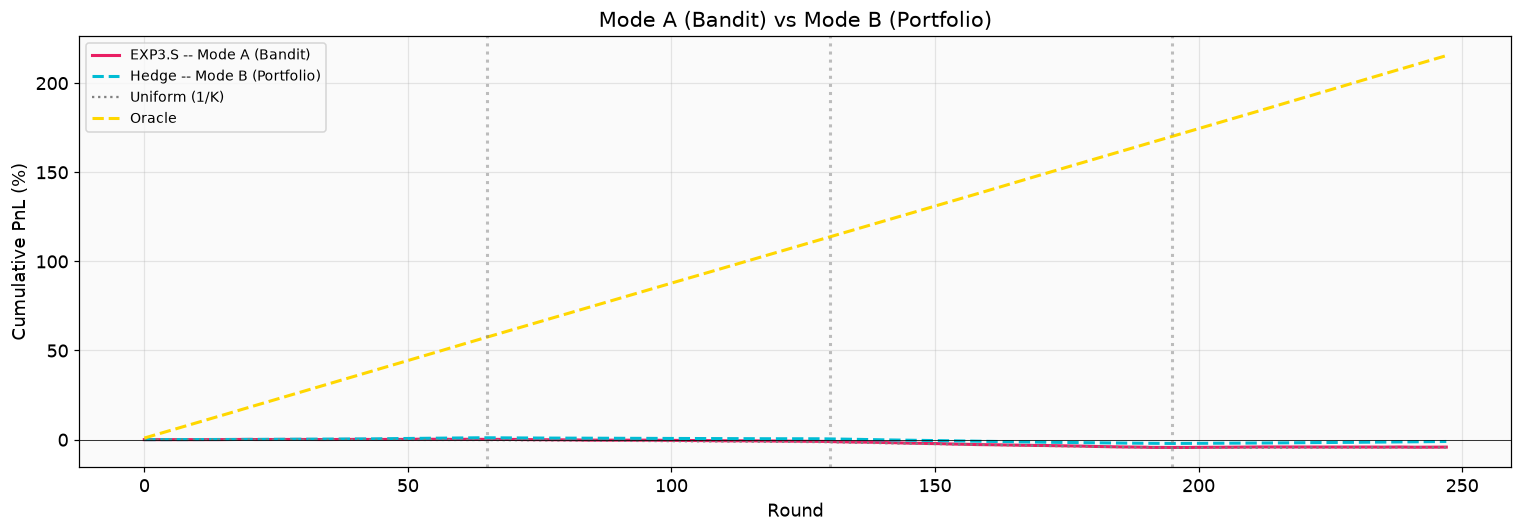

In [11]:
class Hedge:
    """Multiplicative weights for full-information setting."""
    def __init__(self, K, eta=0.1, alpha=0.01):
        self.K = K; self.eta = eta; self.alpha = alpha
        self.reset()
    def reset(self):
        self.w = np.ones(self.K) / self.K
    def get_weights(self):
        return self.w.copy()
    def update_all(self, rewards):
        nr = np.array([norm_reward(r) for r in rewards])
        self.w *= np.exp(self.eta * nr)
        self.w /= np.sum(self.w)
        self.w = (1 - self.alpha) * self.w + self.alpha / self.K


def run_portfolio(factory, pnl_all, n_paths, n_rounds, n_experts):
    """Run portfolio allocation mode."""
    cum = np.zeros((n_paths, n_rounds))
    for p in range(n_paths):
        algo = factory()
        c = 0.0
        for r in range(n_rounds):
            wts = algo.get_weights()
            rv = np.sum(wts * pnl_all[p, r])
            c += rv; cum[p, r] = c
            algo.update_all(pnl_all[p, r])
    return cum


print("Running Mode B (Portfolio) ...")
port_cum = run_portfolio(
    lambda: Hedge(N_EXPERTS, eta=0.1, alpha=0.01),
    pnl, N_PATHS, n_rounds, N_EXPERTS
)

fig, ax = plt.subplots(figsize=(14, 5))

m_a = np.mean(results['EXP3.S']['cumulative_reward'], axis=0) * 100
ax.plot(m_a, label='EXP3.S -- Mode A (Bandit)',
       color=ALGO_COLORS['EXP3.S'], lw=2)

m_b = np.mean(port_cum, axis=0) * 100
ax.plot(m_b, label='Hedge -- Mode B (Portfolio)',
       color='#00BCD4', lw=2, ls='--')

uni_cum = np.cumsum(np.mean(pnl, axis=2), axis=1)
ax.plot(np.mean(uni_cum, axis=0) * 100, label='Uniform (1/K)',
       color='gray', lw=1.5, ls=':')

ax.plot(np.mean(oracle_cum, axis=0) * 100, label='Oracle',
       color=ALGO_COLORS['Oracle'], lw=2, ls='--')

for b in REG_BOUNDS[1:-1]:
    ri = np.searchsorted(round_times, b)
    ax.axvline(ri, color='gray', ls=':', alpha=0.5)
ax.axhline(0, color='black', lw=0.5)
ax.set_title('Mode A (Bandit) vs Mode B (Portfolio)')
ax.set_xlabel('Round'); ax.set_ylabel('Cumulative PnL (%)')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


## 9\. Discussion

### 9.1 Delayed Feedback Impact

The feedback delay (trades closing minutes to hours after opening) **slows down learning** significantly. Traditional MAB algorithms assume instant feedback -- here, by the time an algorithm learns from round $t$'s trade, it may have already made decisions at rounds $t{+}1$ through $t{+}k$. This creates a **staleness** effect.

**Key observation**: non-stationary algorithms (D-UCB, SW-UCB, EXP3.S, Fixed-Share) handle this better because they naturally discount old information, which partially compensates for stale updates.

### 9.2 Regret Control

| Regret type | Achievable? | Comments |
|-------------|-------------|----------|
| Static (vs. best single expert) | Sublinear $O\!\left(\sqrt{T\ln T}\right)$ for UCB1, TS | Standard result; delayed feedback adds a constant factor |
| Dynamic (vs. per-round oracle) | **Linear** | Unavoidable without foresight -- the oracle uses perfect hindsight |

The gap between static and dynamic regret quantifies the **cost of non-stationarity**.

### 9.3 Non-Stationarity Detection

Algorithms with explicit non-stationarity handling adapt faster to regime changes, but depend heavily on **hyperparameter tuning**:

- **D-UCB**: $\gamma$ too close to 1 means slow adaptation; too small means unstable
- **SW-UCB**: window $\tau$ should be proportional to regime length
- **EXP3.S**: mixing $\alpha$ controls exploration/tracking trade-off
- **Fixed-Share**: sharing $\alpha$ controls how quickly the algorithm "forgets"

### 9.4 Stochastic vs. Adversarial Framing

- **UCB family** assumes stochastic rewards (i.i.d. per arm). Valid within a regime, less so across regime changes.
- **EXP3 family** makes no distributional assumptions (adversarial). More robust to regime changes but typically higher per-round regret.

For signal providers, rewards are approximately stochastic within a regime -- so a **non-stationary UCB variant** or **Thompson Sampling** often achieves the best practical performance.

### 9.5 Practical Implications

1. **Don't blindly follow any single provider** -- even the best provider's edge can vanish
2. **Track recent performance, not lifetime averages** -- sliding-window or discounted approaches beat static ones
3. **Portfolio allocation beats binary selection** -- Mode B (portfolio) provides smoother returns
4. **Account for feedback delays** -- don't overreact to recent signals; the full picture takes time


## 10\. Conclusions & Future Work

### Summary

We formulated **signal provider selection** as a Multi-Armed Bandit with:

- **Non-stationary rewards** (4 regimes, 10 experts with varying accuracy)
- **Delayed feedback** (triple-barrier trade exits)
- **Stochastic price** (Geometric Brownian Motion, zero drift)

From 1 000 Monte Carlo simulations:

1. **Non-stationary algorithms** (D-UCB, EXP3.S, Fixed-Share) outperform stationary ones across regime changes
2. **Delayed feedback** slows learning but does not break the MAB framework
3. The choice between **stochastic** (UCB) and **adversarial** (EXP3) depends on the regime structure
4. **Portfolio allocation** (Mode B) provides smoother returns than single-expert sampling (Mode A)

### Future Extensions

- **Multiple assets** with correlated dynamics
- **Variable TP/SL** per expert (different risk profiles)
- **Contextual bandits**: incorporate market features (volatility, trend) into the selection policy
- **Real data validation** with actual provider track records
- **Transaction costs** and position sizing constraints
- **Sleeping bandits**: handle periods where certain experts are inactive
